In [17]:
# SECTION 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# For better visuals
sns.set(style='whitegrid')


In [18]:
# SECTION 2: Load and inspect dataset
df = pd.read_csv('/content/Iris.csv')  # Replace with correct path in your case

# Remove unnecessary ID column
df.drop('Id', axis=1, inplace=True)

# Display first few rows
print(df.head())
print("\nDataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())


   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa

Dataset Shape: (150, 5)

Missing Values:
 SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [19]:
# SECTION 3: Encode target & normalize features

# Encode species to numeric
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

# Separate features and label
X = df.drop('Species', axis=1)
y = df['Species']

# Normalize feature values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [20]:
# SECTION 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


In [21]:
# SECTION 5: Train initial KNN model
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Predict and evaluate
y_pred = knn.predict(X_test)

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy Score: 0.9333333333333333

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.83      1.00      0.91        10
           2       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



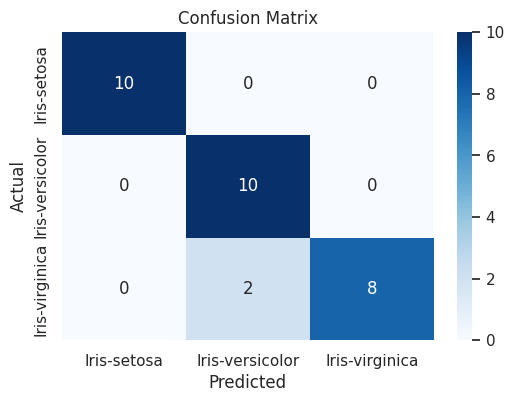

In [22]:
# ADVANCED 1: Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


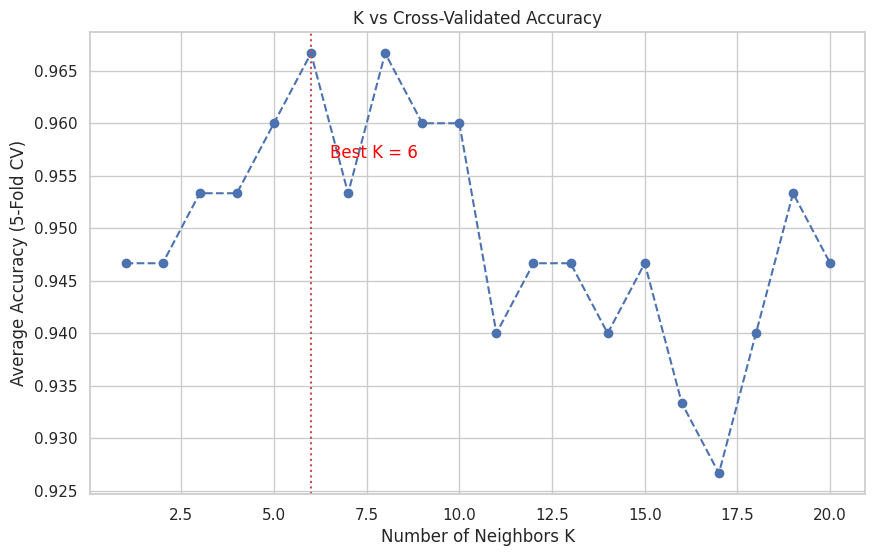

Best K value based on CV: 6 with accuracy: 0.9667


In [23]:
# ADVANCED 2: Cross-validation with different K values
k_range = range(1, 21)
cv_scores = []

for k in k_range:
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_cv, X_scaled, y, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Plotting
plt.figure(figsize=(10,6))
plt.plot(k_range, cv_scores, marker='o', linestyle='--')
plt.title('K vs Cross-Validated Accuracy')
plt.xlabel('Number of Neighbors K')
plt.ylabel('Average Accuracy (5-Fold CV)')

# Mark best point
best_k = k_range[np.argmax(cv_scores)]
plt.axvline(x=best_k, color='r', linestyle=':')
plt.text(best_k+0.5, max(cv_scores)-0.01, f"Best K = {best_k}", color='red')
plt.grid(True)
plt.show()

print(f"Best K value based on CV: {best_k} with accuracy: {max(cv_scores):.4f}")


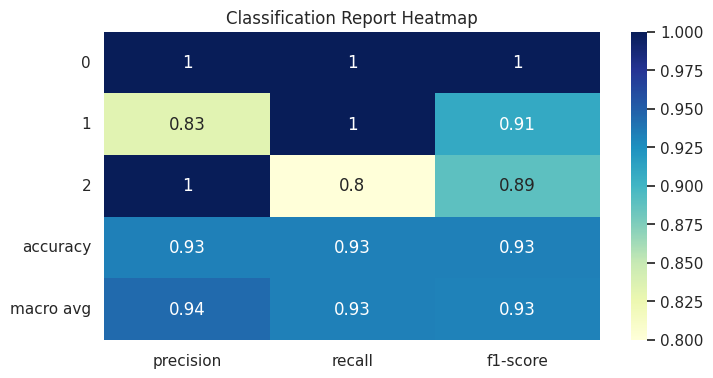

In [24]:
# ADVANCED 3: Visualize classification report
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Convert report to dictionary
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Plot
plt.figure(figsize=(8, 4))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap="YlGnBu")
plt.title("Classification Report Heatmap")
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


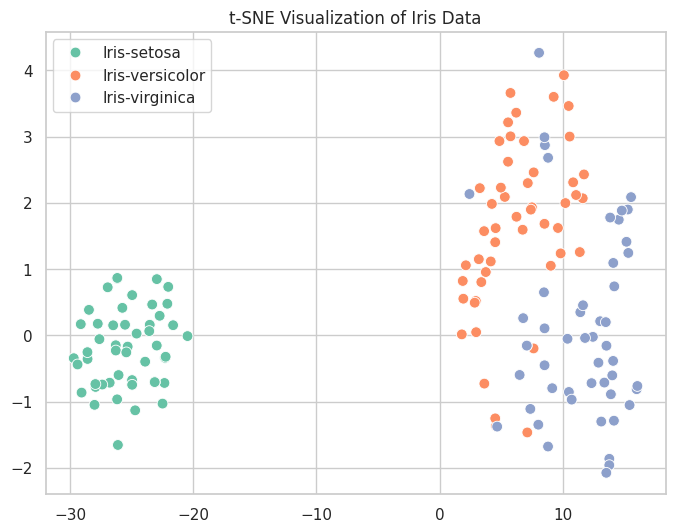

In [25]:
# ADVANCED 4: Visualize data with t-SNE
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=le.inverse_transform(y), palette="Set2", s=60)
plt.title("t-SNE Visualization of Iris Data")
plt.show()


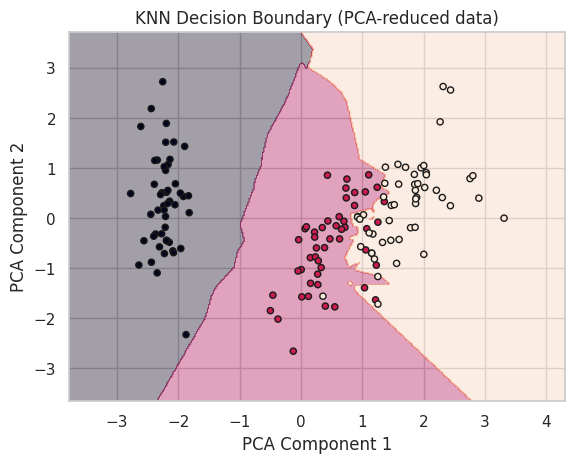

In [26]:
# Visualize Decision Boundaries (2D using PCA)

from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_scaled)

# Split again
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

# Train KNN with best K
knn_pca = KNeighborsClassifier(n_neighbors=3)
knn_pca.fit(X_train_pca, y_train_pca)

# Plot decision boundary
import numpy as np

h = .02
x_min, x_max = X_reduced[:, 0].min() - 1, X_reduced[:, 0].max() + 1
y_min, y_max = X_reduced[:, 1].min() - 1, X_reduced[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = knn_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, edgecolor='k', s=20)
plt.title("KNN Decision Boundary (PCA-reduced data)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()
